# Visualise a serialized image dataset in 2D

Load a prepared dataset artifact, optionally load a MIMIC embedding artifact, first plot a PCA view of the full dataset, then build a separate reference-axis projection from three selected images.

In [32]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
import sys

import numpy as np
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "vision" / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

VISION_SRC = PROJECT_ROOT / "vision" / "src"
if str(VISION_SRC) not in sys.path:
    sys.path.insert(0, str(VISION_SRC))

from mimic_vision.datasets import (
    load_serialized_vision_dataset,
    load_serialized_vision_embedding,
    resolve_artifact_file,
)
from mimic_vision.visualization import (
    compute_2d_embedding,
    plot_image_embedding,
    plot_reference_axis_embedding,
    plot_reference_images,
)

In [34]:
DATASET_FILE = "last"  # Use "last" or an explicit dataset filename.
EMBEDDING_FILE = "last"  # Use "last", None, or an explicit embedding filename.
INPUT_DIR = PROJECT_ROOT / "vision" / "data" / "serialized"
EMBEDDING_DIR = PROJECT_ROOT / "vision" / "data" / "embeddings"
FULL_LAYOUT_METHOD = "pca"
RANDOM_STATE = 0
PROJECTION_SPACE = "raw"  # "raw" or "embedding"

In [35]:
dataset_path = resolve_artifact_file(DATASET_FILE, input_dir=INPUT_DIR, pattern="*.pkl")
DATASET_FILE = dataset_path.name
dataset = load_serialized_vision_dataset(dataset_path)
DATASET_FILE, dataset.X.shape, dataset.images.shape, dataset.y.value_counts().sort_index()

('mnist_train_n120_classes-5-6-8-9_21x21.pkl',
 (120, 441),
 (120, 21, 21),
 target
 5    30
 6    30
 8    30
 9    30
 Name: count, dtype: int64)

## PCA view

Plot the full loaded dataset with PCA coordinates and non-overlapping image thumbnails.

In [36]:
pca_coordinates = compute_2d_embedding(dataset.X, method=FULL_LAYOUT_METHOD, random_state=RANDOM_STATE)
pca_coordinates.shape

(120, 2)

56

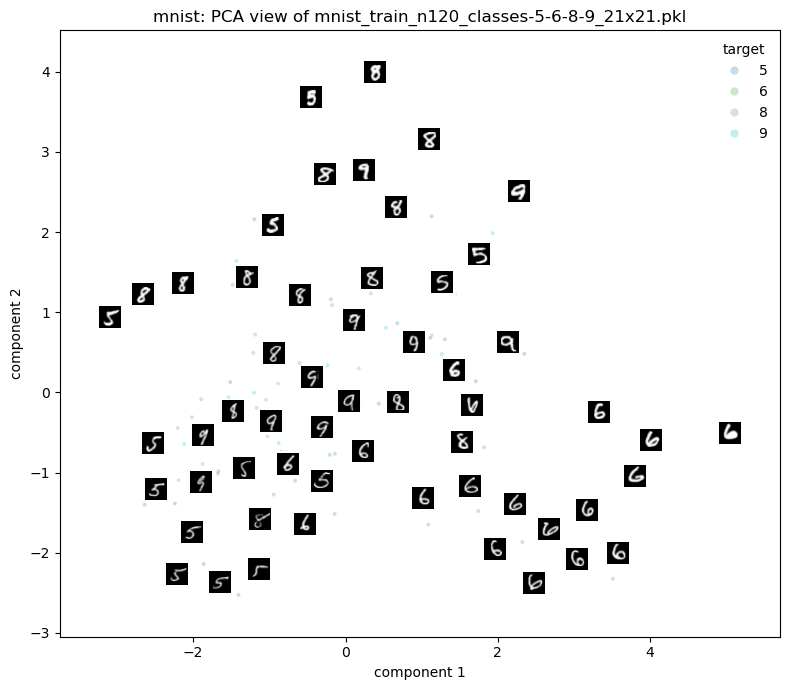

In [37]:
fig_pca, ax_pca, shown_pca = plot_image_embedding(
    pca_coordinates,
    dataset.images,
    labels=dataset.y,
    target_names=dataset.target_names,
    title=f"{dataset.name}: PCA view of {DATASET_FILE}",
    max_images=180,
    min_distance_px=32,
    zoom=.75,
)
len(shown_pca)

## Reference-axis view

Select three reference images `O`, `X`, and `Y`, display them, then project the dataset onto orthogonal axes derived from those references.

In [38]:
embedding_artifact = None
embedding_vectors = None
embedding_status = "not requested"
if EMBEDDING_FILE is not None:
    embedding_pattern = f"{Path(DATASET_FILE).stem}_mimic-*.pkl" if str(EMBEDDING_FILE).lower() == "last" else "*.pkl"
    try:
        embedding_path = resolve_artifact_file(EMBEDDING_FILE, input_dir=EMBEDDING_DIR, pattern=embedding_pattern)
    except FileNotFoundError:
        if str(EMBEDDING_FILE).lower() != "last":
            raise
        embedding_status = f"No matching embedding found for {DATASET_FILE}; using raw vectors."
        EMBEDDING_FILE = None
        PROJECTION_SPACE = "raw"
    else:
        EMBEDDING_FILE = embedding_path.name
        embedding_artifact = load_serialized_vision_embedding(embedding_path)
        if embedding_artifact.dataset_file != DATASET_FILE:
            raise ValueError(f"Embedding artifact was created for {embedding_artifact.dataset_file}, not {DATASET_FILE}.")
        embedding_vectors = embedding_artifact.embeddings
        embedding_status = f"Loaded {EMBEDDING_FILE}"

embedding_status, None if embedding_vectors is None else embedding_vectors.shape

('No matching embedding found for mnist_train_n120_classes-5-6-8-9_21x21.pkl; using raw vectors.',
 None)

{'O': 60, 'X': 55, 'Y': 90}

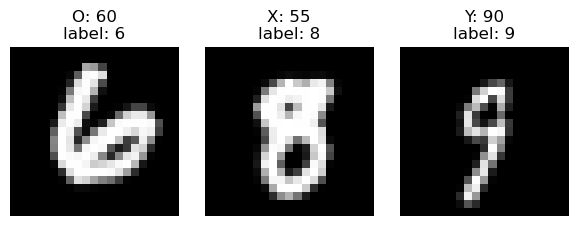

In [39]:
rng = np.random.default_rng(1)
reference_indices = rng.choice(len(dataset.images), size=3, replace=False)
references = dict(zip(["O", "X", "Y"], reference_indices.tolist()))

fig_refs, axes_refs = plot_reference_images(
    dataset.images,
    references,
    labels=dataset.y,
    target_names=dataset.target_names,
)
references

42

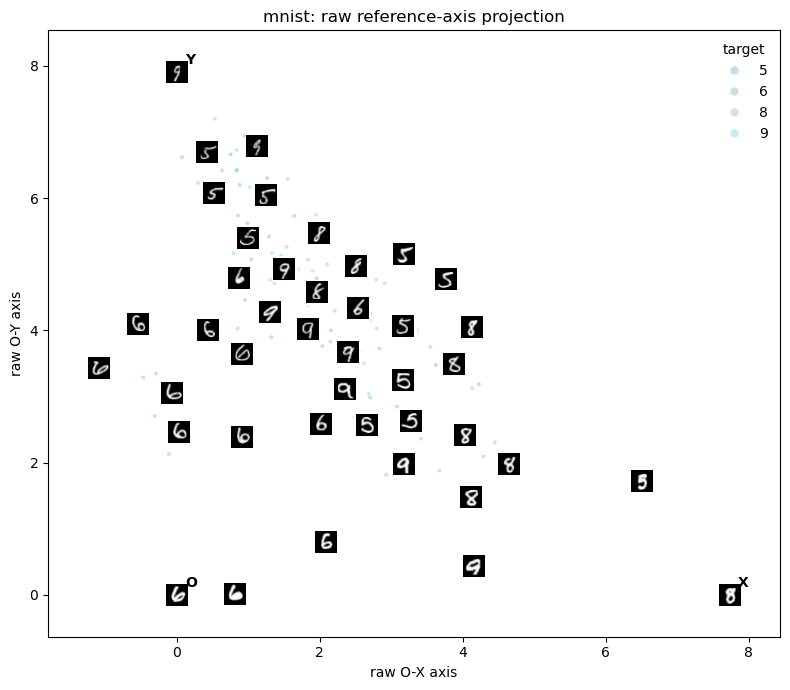

In [40]:
projection_space = PROJECTION_SPACE
if projection_space == "embedding" and embedding_vectors is None:
    projection_space = "raw"

fig_ref, ax_ref, shown_ref, reference_coordinates = plot_reference_axis_embedding(
    dataset.X,
    dataset.images,
    references=references,
    vector_space=projection_space,
    embedding_vectors=embedding_vectors,
    labels=dataset.y,
    target_names=dataset.target_names,
    title=f"{dataset.name}: {projection_space} reference-axis projection",
    max_images=180,
    min_distance_px=32,
    zoom=0.75,
)
len(shown_ref)